# Assignment 9: Causal Inference (Part 2)

## Objective:

Causal inference is the process of drawing a conclusion about a causal connection based on the conditions of the occurrence of an effect. It is a very powerful and widely-used tool in real-world applications and scenarios. In this assignment, you are expected to apply the basic concepts of causal inference to solve problems on real datasets and be able to achieve the following goals.

* Understand why causality is needed.
* Understand what is causality, particularly the difference between causality and correlation.
* Understand how to estimate counterfactual results.
* Understand how to use the graphical model to represent causality.
* Can use some tools (e.g., dowhy) to infer causality, express causality and estimate treatment effects.

# 0. Preparation

In [1]:
import numpy as np
import pandas as pd
# from dataprep.eda import plot
pd.options.mode.chained_assignment = None

In this assignment, you are going to use the [Lalonde](lalonde.csv) dataset. Each tuple in the dataset represents an individual who was enrolled (or not enrolled) in a job training program. It aims to evaluate the effectiveness of a job training program (the treatment variable) on the real earnings of an individual, after completing the program for years. 

The dataset consists of a number of demographic variables, like age, race, academic background, marriage status, and previous real earnings in 1974, 1975 as well as a treatment indicator, and the real earnings in the year 1978 (the outcome variable).

In [2]:
lalonde = pd.read_csv('lalonde.csv', index_col=0)
lalonde.head()
lalonde.head(-5)

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
id,,,,,,,,,,
NSW1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
NSW2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
NSW3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
NSW4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
NSW5,1,33,8,1,0,0,1,0.0,0.0,289.7899
...,...,...,...,...,...,...,...,...,...,...
PSID420,0,39,2,1,0,1,1,0.0,0.0,964.9555
PSID421,0,55,8,0,0,1,1,0.0,0.0,0.0000
PSID422,0,16,9,0,0,0,1,0.0,0.0,5551.8190


## Task 1. Causal Graph 
In this task, you will draw a causal graph on a real-world dataset based on the information given. Please remind yourself of the difference between causality and correlation.

In [4]:
#import graphviz, the python tool we are going to use for this task
from graphviz import Digraph

In the Lalonde dataset, `treat` is the treatment attribute, which represents whether an individual was enrolled in the job training program or not. `re78` is the outcome attribute. `age` and `married` are confounding variables. Please draw the causal graph for these four attributes using Graphviz.

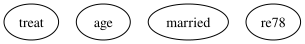

In [5]:
dot = Digraph(comment='The causal graph for Lalonde')
dot.node('a','treat')
dot.node('b','age')
dot.node('c','married')
dot.node('d','re78')

dot

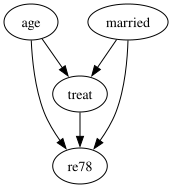

In [ ]:
dot.edge('b', 'a')
dot.edge('b', 'd')
dot.edge('c', 'a')
dot.edge('c', 'd')
dot.edge('a', 'd')

dot

## Task 2. ATE Estimation
In this task, your job is to implement different AET estimation approaches and draw useful conclusions.

### 2.1 Perfect Matching
For the PSID tuples in the dataset (i.e., those individuals who weren't enrolled in the job training program), please use perfect matching to estimate their salaries if they received treatments?


In [7]:
# Implement the perfect matching method here and output the count of PSID tuples whose counterfactual can be computed
# using perfect matching, as well as the percentage of such tuples among all PSID tuples. If there are multiple 
# tuples in the treatment group that can be matched with the control group, just select the first one
# output: count and percentage

control = lalonde[lalonde['treat'] == 0].copy()
treated = lalonde[lalonde['treat'] == 1].copy()
covariates = [col for col in lalonde.columns if col not in ['treat', 're78']]

perfect_matches = {}

for control_idx, control_row in control.iterrows():
    matched = treated
    for col in covariates:
        matched = matched[matched[col] == control_row[col]]
        if matched.empty:
            break
    if not matched.empty:
        perfect_matches[control_idx] = matched.index[0]

count = len(perfect_matches)
percentage = count / len(control)

In [8]:
# Run the following code to print out the result
print("Count of tuples which can be computed by perfect matching is " + str(count))
print("Percentage of such tuples among all PSID tuples is " + str(percentage))

Count of tuples which can be computed by perfect matching is 12
Percentage of such tuples among all PSID tuples is 0.027972027972027972


In [9]:
# Compute ATE among those PSID tuples whose counterfactual can be computed using perfect matching
# output: value of ATE

ATE = np.mean([
    treated.loc[treated_idx, 're78'] - control.loc[control_idx, 're78']
    for control_idx, treated_idx in perfect_matches.items()
])

In [10]:
# Run following code to print the result
print("ATE by perfect matching is " + str(ATE))

ATE by perfect matching is 1362.394


### 2.2 Nearest Neighbor Matching
For the PSID tuples in the dataset (i.e., those who weren't enrolled in the job training program), please use the nearest neighbor matching to estimate their salaries if they received treatments?

Please use all covariates (the attributes besides treatment and outcome) and use Euclidean distance as the distance metric.

In [11]:
# Implement the nearest neighbor matching method here and output the count of PSID tuples whose counterfactual can be
# computed using nearest neighbor matching, when the threshold is set to 1000, as well as the percentage of such tuples among all PSID tuples
# Output: count and percentage

# Please use np.linalg.norm(x1 - x2) to compute the euclidean distance between two vectors

control = lalonde[lalonde['treat'] == 0].copy()
treated = lalonde[lalonde['treat'] == 1].copy()
covariates = [col for col in lalonde.columns if col not in ['treat', 're78', 'psm']]

nn_matches = {}

for control_idx, control_row in control.iterrows():
    control_x = control_row[covariates].to_numpy(dtype=float)
    distances = treated[covariates].apply(
        lambda row: np.linalg.norm(row.to_numpy(dtype=float) - control_x),
        axis=1
    )
    nearest_idx = distances.idxmin()
    nearest_distance = distances.loc[nearest_idx]
    if nearest_distance <= 1000:
        nn_matches[control_idx] = nearest_idx

count = len(nn_matches)
percentage = count / len(control)

In [12]:
#run following code to print the result
print("Count of tuples which can be computed by nearest neighbor matching is " + str(count))
print("Percentage of such tuples among all PSID tuples is " + str(percentage))

Count of tuples which can be computed by nearest neighbor matching is 318
Percentage of such tuples among all PSID tuples is 0.7412587412587412


In [ ]:
# Compute ATE among those PSID tuples whose counterfactual can be computed using nearest neighbor matching
# Output: value of ATE

ATE = np.mean([
    treated.loc[treated_idx, 're78'] - control.loc[control_idx, 're78']
    for control_idx, treated_idx in nn_matches.items()
])

In [14]:
# Run following code to print out the result
print("ATE by nearest neighbor matching is " + str(ATE))

ATE by nearest neighbor matching is 519.1813407232705


### 2.3 Propensity Score Matching
For the PSID tuples in the dataset (i.e., those weren't enrolled in the job training program), please use propensity score matching to estimate their salaries if they received treatments?

Please use logistic regression to fit the propensity score.

In [15]:
# Compute propensity score P(y = 1|X) for each tuple in the dataset. Use logistic regression.
# Output: add the new column "psm" to lalonde dataframe

from sklearn.linear_model import LogisticRegression

covariates = [col for col in lalonde.columns if col not in ['treat', 're78']]
X = lalonde[covariates]
y = lalonde['treat']

psm_model = LogisticRegression(max_iter=2000)
psm_model.fit(X, y)
lalonde['psm'] = psm_model.predict_proba(X)[:, 1]

In [16]:
# Run the following code to see the result
lalonde.head()

,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78,psm
id,,,,,,,,,,,
NSW1,1,37,11,1,0,1,1,0.0,0.0,9930.0460,0.621637
NSW2,1,22,9,0,1,0,1,0.0,0.0,3595.8940,0.209204
NSW3,1,30,12,1,0,0,0,0.0,0.0,24909.4500,0.668309
NSW4,1,27,11,1,0,0,1,0.0,0.0,7506.1460,0.759049
NSW5,1,33,8,1,0,0,1,0.0,0.0,289.7899,0.689154


In [17]:
# For each tuple in the control group, find the matching tuple in the treatment group, and then compute
# the ATE over the population
# Please match tuples with the metric |psm1 - psm2| to be minimum, threhold set to 0.01
# Output: the value of ATE, the count of tuples that can be matched, as well as the percentage

control = lalonde[lalonde['treat'] == 0].copy()
treated = lalonde[lalonde['treat'] == 1].copy()

psm_matches = {}

for control_idx, control_row in control.iterrows():
    distances = (treated['psm'] - control_row['psm']).abs()
    nearest_idx = distances.idxmin()
    nearest_distance = distances.loc[nearest_idx]
    if nearest_distance <= 0.01:
        psm_matches[control_idx] = nearest_idx

count = len(psm_matches)
percentage = count / len(control)
ATE = np.mean([
    treated.loc[treated_idx, 're78'] - control.loc[control_idx, 're78']
    for control_idx, treated_idx in psm_matches.items()
])

In [18]:
# Run the following code to print out the result
print("ATE by propensity score matching is " + str(ATE))
print("Count of tuples which can be computed by propensity score matching is " + str(count))
print("Percentage of such tuples among all PSID tuples is " + str(percentage))

ATE by propensity score matching is 644.3434285897433
Count of tuples which can be computed by propensity score matching is 390
Percentage of such tuples among all PSID tuples is 0.9090909090909091


### 2.4 Linear Regression
Train two individual models to fit P(y|t = 1,X) and P(y|t = 0,X), then infer the counterfactual outcome using two models while setting treatment to the opposite value. Infer the ATE over the population.

In [20]:
# Train two individual linear regression models and infer the counterfactual result for each tuple
# Output: the value of ATE, over the population

from sklearn.linear_model import LinearRegression

covariates = [col for col in lalonde.columns if col not in ['treat', 're78', 'psm']]
treated = lalonde[lalonde['treat'] == 1].copy()
control = lalonde[lalonde['treat'] == 0].copy()

treated_model = LinearRegression()
control_model = LinearRegression()

treated_model.fit(treated[covariates], treated['re78'])
control_model.fit(control[covariates], control['re78'])

treated_pred = treated_model.predict(lalonde[covariates])
control_pred = control_model.predict(lalonde[covariates])
ATE = np.mean(treated_pred - control_pred)


In [21]:
# Run following code to print out the result
print("ATE by linear regression is " + str(ATE))

ATE by linear regression is 1074.9085413949438


Please briefly discuss the advantages and disadvantages of the above four approaches.

**A.** Perfect matching is simple and easy to interpret because it compares units with exactly the same covariates, but it is very strict and usually matches only a small number of tuples. Nearest neighbor matching is more flexible and can match many more tuples, but the matched units may still be quite different, so the estimate can be sensitive to poor matches and the distance threshold. Propensity score matching reduces many covariates into one score and often improves matching coverage, but its quality depends on how well the logistic regression model estimates treatment assignment, and it still cannot control for unobserved confounders. Linear regression uses all tuples and is computationally convenient, but it relies on the correctness of the model form, so if the linear relationship is misspecified, the estimated ATE may be biased.

## Task 3. DoWhy
In this task, you are required to apply DoWhy and analyze the dataset using two ATE estimation methods.

In [25]:
from dowhy import CausalModel
lalonde['treat'] = lalonde['treat'].astype(bool)
model = CausalModel(
        data = lalonde,
        treatment='treat',
        outcome='re78',
        common_causes='nodegree+black+hispan+age+educ+married'.split('+'))


In [26]:
# Use the linear regression and PSM methods provided by DoWhy to estimate ATE 
# Output: ATE_linear, ATE_psm

identified_estimand = model.identify_effect()

linear_estimate = model.estimate_effect(
    identified_estimand,
    method_name='backdoor.linear_regression'
)

psm_estimate = model.estimate_effect(
    identified_estimand,
    method_name='backdoor.propensity_score_matching'
)

ATE_linear = linear_estimate.value
ATE_psm = psm_estimate.value

In [27]:
# Run following code to print out the result
print("ATE by linear regression is " + str(ATE_linear))
print("ATE by psm is " + str(ATE_psm))

ATE by linear regression is 1163.9223548829032
ATE by psm is 285.6763360423453


Briefly explain why the result by DoWhy is not same as the result by your own implementation.

**A.** The result from DoWhy is not exactly the same as my own implementation because the estimation procedures are not identical in detail. My code uses simplified matching rules, thresholds, and model settings, while DoWhy uses its own built-in implementation and defaults. In addition, my matching-based methods compute the effect only on matched tuples, while DoWhy may use a different matching procedure or sample handling. Therefore, even when the two approaches use the same general idea, the estimated ATE can still be different.

## Submission

Complete the code in this notebook, and submit it to Canvas.